# Towards a GIS system

In [ ]:
#| default_exp database

In [ ]:
#| export
import numpy as np
import sys
import os
import math
from math import radians, cos, sin, sqrt, atan2
import random

#data
from collections import namedtuple
from dataclasses import dataclass,  field, asdict
import json
from typing import List , Optional
from enum import Enum



In [ ]:
#| export
from dataclasses import dataclass
from typing import Optional

from datetime import datetime


In [ ]:
#| export
from fastcore.utils import *
from fasthtml.common import *
from fasthtml.jupyter import *
from fastlite import *
import fasthtml.components as fc
import httpx


In [ ]:
#| export
from importlib import resources
from pathlib import Path
import tempfile
import shutil
import sqlite3


In [ ]:
#| export
from HexMagic.climate import TerrainPatterns, DrainageBasins, Geology, TerraDemo, Terrain, GeoBounds, ClimatePreset, TerrainFactory
from HexMagic.primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge
from HexMagic.styles import StyleCSS, SVGBuilder

In [ ]:
#| export
import asyncio
from dataclasses import dataclass

In [ ]:
#!cat *.md

In [ ]:
#!cat ../llms.txt

## Helpers

In [ ]:
#| export
LoadResult = namedtuple('LoadResult', ['data', 'status', 'context'])
SaveResult = namedtuple('SaveResult', ['id', 'status', 'context'])

## Tables

In [ ]:
#| export
@dataclass  
class HexData:
    id: int = None
    world_id: int = 0
    q: int = 0
    r: int = 0
    s: int = 0
    grid_index: int = 0
    elevation: float = 0.0
    latitude: Optional[float] = None
    longitude: Optional[float] = None
    distance_from_coast: Optional[float] = None
    modified: int = 0


In [ ]:
#| export
@dataclass
class HexWeather:
    """Weather data for a hex at a point in time."""
    id: int = None
    world_id: int = 0
    q: int = 0
    r: int = 0
    s: int = 0
    # Core weather fields
    temperature: float = 0.0           # °C
    precipitation: float = 0.0         # mm/year
    humidity: Optional[float] = None   # %
    # Derived/computed fields
    climate_pet: Optional[float] = None          # potential evapotranspiration
    aridity_index: Optional[float] = None
    temp_seasonality: Optional[float] = None
    precip_seasonality: Optional[float] = None
    distance_from_coast: Optional[float] = None  # hex units
    # Temporal
    season: str = ""                   # e.g., "annual", "summer", "winter"
    modified: int = 0


In [ ]:
#| export


@dataclass
class TerrainWorld:
    """Metadata for a stored terrain."""
    id: int = None
    name: str = ""
    hex_radius: float = 25.0
    nrows: int = 0
    ncols: int = 0
    sea_level: float = 0.0
    elevation_delta: float = 90.0
    # Encoded extras (climate, geo bounds, etc)
    extras: str = ""
    created: int = 0
    modified: int = 0



In [ ]:
#| export
@dataclass
class User:
    username: str
    email: str
    password: str
    created: int  # Unix timestamp
    sessionID: str
    activeWorld: int # a link into world_id for world 
    id: int = None

## Main Storage

In [ ]:
#| export
class GeoStorage:

    def __init__(self, custom_path=None):
        path = GeoStorage.get_db_path(custom_path)
        self.path = path
        self.createDB()

    def createDB(self):
        db = database(self.path)
        self.db = db

        # Create tables using dataclasses
        db.create(TerrainWorld, pk='id', if_not_exists=True, transform=True)
        db.create(HexData, pk='id', if_not_exists=True, transform=True)
        db.create(User, pk='id', if_not_exists=True, transform=True)

        # After creating tables
        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_world ON hex_data(world_id)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_coords ON hex_data(world_id, q, r, s)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_grid ON hex_data(world_id, grid_index)")

        db.execute("CREATE INDEX IF NOT EXISTS idx_hex_temporal ON hex_data(world_id, q, r, s, modified DESC)")

        db.create(HexWeather, pk='id', if_not_exists=True, transform=True)

        # Indices for weather queries
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_world ON hex_weather(world_id)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_coords ON hex_weather(world_id, q, r, s)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_temporal ON hex_weather(world_id, q, r, s, modified DESC)")
        db.execute("CREATE INDEX IF NOT EXISTS idx_weather_season ON hex_weather(world_id, season)")

        self.weather = db.t.hex_weather

        

        # Store table references using db.t notation
        self.users = db.t.user
        self.hexes = db.t.hex_data
        self.worlds = db.t.terrain_world

        
        
        # Populate templates (after tables exist)
        #self.populate_templates()


    @staticmethod
    def get_db_path(custom_path=None):
        """Get database path. Tries package data, falls back to user directory."""
        if custom_path:
            return custom_path
        
        # Try package data directory first
        try:
            db_dir = resources.files('HexMagic').joinpath('data/db')
            db_path = Path(db_dir) / 'hexmagic.db'
            # Test if writable
            db_path.parent.mkdir(parents=True, exist_ok=True)
            db_path.touch(exist_ok=True)
            return str(db_path)
        except (PermissionError, OSError):
            # Fallback to user directory
            data_dir = Path.home() / '.hexmagic' / 'data'
            data_dir.mkdir(parents=True, exist_ok=True)
            return str(data_dir / 'hexmagic.db')

    def __enter__(self):
        return self

    def __exit__(self, *args):
        self.db.close()

    
    @staticmethod
    def _get(obj, key):
        """Get attribute from dict or object."""
        return obj[key] if isinstance(obj, dict) else getattr(obj, key)

In [ ]:
#| export


#this might be something we don't export
@patch
def reset_database(self:GeoStorage):
    """Delete and recreate database. USE WITH CAUTION!"""
    db_path = Path(self.path)  # Convert string to Path
    
    if db_path.exists():
        db_path.unlink()

    self.createDB()



In [ ]:
#| export

@patch
def _latest_hex_subquery(self: GeoStorage, world_id: int, as_of: int = None) -> str:
    """SQL subquery for latest hex state, optionally at a point in time."""
    time_clause = f"AND modified <= {as_of}" if as_of else ""
    return f"""
        SELECT world_id, q, r, s, MAX(modified) as max_mod
        FROM hex_data
        WHERE world_id = {world_id} {time_clause}
        GROUP BY world_id, q, r, s
    """




In [ ]:
@patch
def query_hexes_latest(self: GeoStorage, world_id: int, as_of: int = None) -> list:
    """Get most recent version of each hex, optionally at a specific time."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    cursor = self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
    """)
    
    # Get column names from cursor description
    cols = [d[0] for d in cursor.description]
    rows = [dict(zip(cols, row)) for row in cursor.fetchall()]
    
    return rows


In [ ]:
@patch
def update_hex(self: GeoStorage, world_id: int, q: int, r: int, s: int,
               elevation: float = None, latitude: float = None, longitude: float = None,
               distance_from_coast: float = None, grid_index: int = None) -> SaveResult:
    """Append a new state for a hex (temporal update)."""
    now = int(datetime.now().timestamp())
    
    record = {
        'world_id': world_id,
        'q': q, 'r': r, 's': s,
        'modified': now
    }
    
    # Get previous state to preserve unchanged fields
    prev = self.query_hexes_in_radius(world_id, q, r, s, radius=0)
    if prev:
        prev = prev[0]
        record['grid_index'] = grid_index if grid_index is not None else GeoStorage._get(prev, 'grid_index')
        record['elevation'] = elevation if elevation is not None else GeoStorage._get(prev, 'elevation')
        record['latitude'] = latitude if latitude is not None else GeoStorage._get(prev, 'latitude')
        record['longitude'] = longitude if longitude is not None else GeoStorage._get(prev, 'longitude')
        record['distance_from_coast'] = distance_from_coast if distance_from_coast is not None else GeoStorage._get(prev, 'distance_from_coast')
    else:
        record['grid_index'] = grid_index or 0
        record['elevation'] = elevation or 0.0
        record['latitude'] = latitude
        record['longitude'] = longitude
        record['distance_from_coast'] = distance_from_coast
    
    try:
        self.hexes.insert(record)
        return SaveResult(None, 'updated', f'hex ({q},{r},{s}) at {now}')
    except Exception as e:
        return SaveResult(None, 'error', str(e))


### World

In [ ]:
#| export
@patch
def save_world(self: GeoStorage, terrain: Terrain, name: str = "") -> SaveResult:
    """Save terrain to database. Returns SaveResult(world_id, status, context)."""
    now = int(datetime.now().timestamp())
    
    grid = terrain.hexGrid
    
    # Build extras dict for non-field data
    extras = {}
    if terrain.geo:
        extras['geo'] = terrain.geo.encode() if hasattr(terrain.geo, 'encode') else str(terrain.geo)
    if terrain.climate:
        extras['climate'] = terrain.climate.encode() if hasattr(terrain.climate, 'encode') else str(terrain.climate)
    
    try:
        with self.db.conn:  # Transaction
            # Insert world metadata
            world_result = self.worlds.insert({
                'name': name or f"World_{now}",
                'hex_radius': grid.radius,
                'nrows': grid.nRows,
                'ncols': grid.nCols,
                'sea_level': terrain.seaLevel if isinstance(terrain.seaLevel, (int, float)) else 0.0,
                'elevation_delta': terrain.elevationDelta,
                'extras': json.dumps(extras),
                'created': now,
                'modified': now
            })
            
            world_id = world_result['id'] if isinstance(world_result, dict) else world_result
            
            # Insert hex data
            hex_records = []
            for idx, hex_obj in enumerate(grid.hexes):
                pos = grid.index_to_hexposition(idx)
                
                # Get lat/lon if geo bounds available
                lat, lon = None, None
                if terrain.geo and hasattr(terrain.geo, 'pixel_to_latlon'):
                    center = hex_obj.center
                    # Calculate grid pixel dimensions
                    width = grid.nCols * grid.radius * 1.5 + grid.radius
                    height = grid.nRows * grid.radius * math.sqrt(3) + grid.radius
                    lat, lon = terrain.geo.pixel_to_latlon(center.x, center.y, width, height)

                
                dist_coast = None
                if 'distance_to_ocean' in terrain.fields:
                    dist_coast = float(terrain.fields['distance_to_ocean'][idx])
                
                hex_records.append({
                    'world_id': world_id,
                    'q': pos.q,
                    'r': pos.r,
                    's': pos.s,
                    'grid_index': idx,
                    'elevation': float(terrain.elevations[idx]),
                    'latitude': lat,
                    'longitude': lon,
                    'distance_from_coast': dist_coast,
                    'modified': now
                })
            
            # Batch insert
            for record in hex_records:
                self.hexes.insert(record)
            
            return SaveResult(world_id, 'saved', f'{len(hex_records)} hexes')
    
    except Exception as e:
        return SaveResult(None, 'error', str(e))


In [ ]:
#| export
@patch
def load_world(self: GeoStorage, world_id: int, as_of: int = None) -> LoadResult:
    """Load terrain from database. 
    
    Args:
        world_id: World to load
        as_of: Optional Unix timestamp - load state at this point in time
    
    Returns LoadResult(terrain, status, context).
    """
    try:
        world = self.worlds[world_id]
        if not world:
            return LoadResult(None, 'not_found', f'World {world_id} not found')
        
        radius = GeoStorage._get(world, 'hex_radius')
        nrows = GeoStorage._get(world, 'nrows')
        ncols = GeoStorage._get(world, 'ncols')
        
        width = ncols * radius * 1.5 + radius
        height = nrows * radius * math.sqrt(3) + radius
        bounds = MapRect(MapCord(0, 0), MapSize(width, height))
        
        terrain = Terrain(bounds, radius=radius)
        terrain.hexGrid.nRows = nrows
        terrain.hexGrid.nCols = ncols
        terrain.hexGrid.adjustRadius(radius)
        terrain.elevations = np.zeros(len(terrain.hexGrid.hexes))
        terrain.elevationDelta = GeoStorage._get(world, 'elevation_delta')
        
        # Use temporal query
        hex_rows = self.query_hexes_latest(world_id, as_of=as_of)
        
        for row in hex_rows:
            idx = GeoStorage._get(row, 'grid_index')
            terrain.elevations[idx] = GeoStorage._get(row, 'elevation')
            
            dist = GeoStorage._get(row, 'distance_from_coast')
            if dist is not None:
                if 'distance_to_ocean' not in terrain.fields:
                    terrain.fields['distance_to_ocean'] = np.zeros(len(terrain.elevations))
                terrain.fields['distance_to_ocean'][idx] = dist
        
        extras_str = GeoStorage._get(world, 'extras')
        if extras_str:
            extras = json.loads(extras_str)
        
        time_info = f" as of {as_of}" if as_of else ""
        return LoadResult(terrain, 'loaded', f'{len(hex_rows)} hexes{time_info}')
    
    except Exception as e:
        return LoadResult(None, 'error', str(e))


### Region

In [ ]:
@patch
def query_hexes_in_radius(self: GeoStorage, world_id: int,
                          center_q: int, center_r: int, center_s: int,
                          radius: int, as_of: int = None) -> list:
    """Query latest hexes within radius of a center position."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    cursor = self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.q BETWEEN ? AND ? AND h.r BETWEEN ? AND ?
    """, [
        center_q - radius, center_q + radius,
        center_r - radius, center_r + radius
    ])
    
    # Convert to dicts like query_hexes_latest does
    cols = [d[0] for d in cursor.description]
    rows = [dict(zip(cols, row)) for row in cursor.fetchall()]
    
    # Filter to actual hex distance
    result = []
    for row in rows:
        dq = abs(GeoStorage._get(row, 'q') - center_q)
        dr = abs(GeoStorage._get(row, 'r') - center_r)
        ds = abs(GeoStorage._get(row, 's') - center_s)
        dist = max(dq, dr, ds)
        if dist <= radius:
            result.append(row)
    
    return result


In [ ]:
@patch
def extract_region(self: GeoStorage, world_id: int,
                   center_q: int, center_r: int, center_s: int,
                   rings: int, padding: int = 1, as_of: int = None) -> LoadResult:
    """Extract a centered region as a new Terrain.
    
    Returns LoadResult(terrain, status, context)
    """
    world = self.worlds[world_id]
    if not world:
        return LoadResult(None, 'not_found', f'World {world_id} not found')
    
    radius = GeoStorage._get(world, 'hex_radius')
    
    # Query hexes in region
    hex_rows = self.query_hexes_in_radius(world_id, center_q, center_r, center_s, rings, as_of=as_of)
    if not hex_rows:
        return LoadResult(None, 'empty', 'No hexes found in region')
    
    # Create centered grid
    total_rings = rings + padding
    grid = HexGrid.centered(radius=radius, rings=total_rings, style=StyleCSS("simple"))
    
    # Build terrain
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = grid
    terrain.elevations = np.zeros(len(grid.hexes))
    terrain.fields = {}
    terrain.elevationDelta = GeoStorage._get(world, 'elevation_delta')
    terrain.seaLevel = GeoStorage._get(world, 'sea_level')
    terrain.climate = None
    terrain.path = ""
    terrain.colorLevels = None
    
    # Compute GeoBounds from extracted hexes
    lats = [GeoStorage._get(r, 'latitude') for r in hex_rows if GeoStorage._get(r, 'latitude') is not None]
    lons = [GeoStorage._get(r, 'longitude') for r in hex_rows if GeoStorage._get(r, 'longitude') is not None]
    
    if lats and lons:
        terrain.geo = GeoBounds(
            lat_min=min(lats), lat_max=max(lats),
            lon_min=min(lons), lon_max=max(lons)
        )

    else:
        terrain.geo = None
    
    # Map DB rows to centered grid
    filled = 0
    
    for row in hex_rows:
        # Position relative to query center
        q = GeoStorage._get(row, 'q') - center_q
        r = GeoStorage._get(row, 'r') - center_r
        s = GeoStorage._get(row, 's') - center_s
        rel_pos = HexPosition(q, r, s)
        
        # Map to centered grid
        new_idx = grid.hexposition_to_index(rel_pos, origin_index=grid.middle)
        if 0 <= new_idx < len(grid.hexes):
            terrain.elevations[new_idx] = GeoStorage._get(row, 'elevation')
            
            dist = GeoStorage._get(row, 'distance_from_coast')
            if dist is not None:
                if 'distance_to_ocean' not in terrain.fields:
                    terrain.fields['distance_to_ocean'] = np.zeros(len(grid.hexes))
                terrain.fields['distance_to_ocean'][new_idx] = dist
            
            filled += 1
    
    return LoadResult(terrain, 'extracted', f'{filled}/{len(hex_rows)} hexes mapped')


In [ ]:
def create_region_coord_mapper(center_q: int, center_r: int, center_s: int, 
                                extracted_grid: HexGrid) -> callable:
    """Create mapper from extracted region index to original world (q,r,s).
    
    Args:
        center_q, center_r, center_s: The center point used for extraction
        extracted_grid: The centered grid from extract_region
    
    Returns:
        Function: new_idx -> (q, r, s) tuple in original world coords
    """
    def mapper(new_idx: int) -> tuple[int, int, int]:
        # Get position relative to extracted grid's center
        rel_pos = extracted_grid.index_to_hexposition(new_idx, origin_index=extracted_grid.middle)
        # Add back the world center offset
        return (center_q + rel_pos.q, center_r + rel_pos.r, center_s + rel_pos.s)
    
    return mapper


In [ ]:
@patch
def create_region_index_mapper(self: GeoStorage, world_id: int,
                                center_q: int, center_r: int, center_s: int,
                                extracted_grid: HexGrid) -> callable:
    """Create mapper from extracted region index to original world grid_index.
    
    Args:
        world_id: The source world
        center_q, center_r, center_s: The center point used for extraction
        extracted_grid: The centered grid from extract_region
    
    Returns:
        Function: new_idx -> original_grid_index (or -1 if not in world)
    """
    # Build lookup dict from DB (q,r,s) -> grid_index
    hex_rows = list(self.hexes.rows_where('world_id = ?', [world_id]))
    coord_to_idx = {
        (GeoStorage._get(r, 'q'), GeoStorage._get(r, 'r'), GeoStorage._get(r, 's')): 
        GeoStorage._get(r, 'grid_index')
        for r in hex_rows
    }
    
    def mapper(new_idx: int) -> int:
        rel_pos = extracted_grid.index_to_hexposition(new_idx, origin_index=extracted_grid.middle)
        world_coords = (center_q + rel_pos.q, center_r + rel_pos.r, center_s + rel_pos.s)
        return coord_to_idx.get(world_coords, -1)
    
    return mapper


### Weather

In [ ]:
#| export
@patch
def save_weather(self: GeoStorage, terrain: Terrain, world_id: int, 
                 season: str = "annual") -> SaveResult:
    """Save weather data for a terrain to database.
    
    Args:
        terrain: Terrain with weather fields computed
        world_id: World ID to associate weather with
        season: Season identifier (e.g., "annual", "summer", "winter")
    
    Returns:
        SaveResult(count, status, context)
    """
    now = int(datetime.now().timestamp())
    grid = terrain.hexGrid
    
    # Check for required weather fields
    if 'temperature' not in terrain.fields or 'precipitation' not in terrain.fields:
        return SaveResult(None, 'error', 'Missing temperature or precipitation fields')
    
    try:
        with self.db.conn:
            records = []
            for idx in range(len(terrain.elevations)):
                pos = grid.index_to_hexposition(idx)
                
                record = {
                    'world_id': world_id,
                    'q': pos.q,
                    'r': pos.r,
                    's': pos.s,
                    'temperature': float(terrain.fields['temperature'][idx]),
                    'precipitation': float(terrain.fields['precipitation'][idx]),
                    'humidity': float(terrain.fields['humidity'][idx]) if 'humidity' in terrain.fields else None,
                    'climate_pet': float(terrain.fields['climate_pet'][idx]) if 'climate_pet' in terrain.fields else None,
                    'aridity_index': float(terrain.fields['aridity_index'][idx]) if 'aridity_index' in terrain.fields else None,
                    'temp_seasonality': float(terrain.fields['temp_seasonality'][idx]) if 'temp_seasonality' in terrain.fields else None,
                    'precip_seasonality': float(terrain.fields['precip_seasonality'][idx]) if 'precip_seasonality' in terrain.fields else None,
                    'distance_from_coast': float(terrain.fields['distance_to_coast'][idx]) if 'distance_to_coast' in terrain.fields else None,
                    'season': season,
                    'modified': now
                }
                records.append(record)
            
            for record in records:
                self.weather.insert(record)
            
            return SaveResult(len(records), 'saved', f'{len(records)} weather records for season={season}')
    
    except Exception as e:
        return SaveResult(None, 'error', str(e))




In [ ]:
#| export

@patch
def load_weather(self: GeoStorage, world_id: int, terrain: Terrain,
                 season: str = "annual", as_of: int = None) -> LoadResult:
    """Load weather data into a terrain's fields.
    
    Args:
        world_id: World ID to load weather for
        terrain: Terrain to populate with weather fields
        season: Season to load
        as_of: Optional timestamp for temporal query
    
    Returns:
        LoadResult(terrain, status, context)
    """
    try:
        # Build temporal subquery
        time_clause = f"AND modified <= {as_of}" if as_of else ""
        
        cursor = self.db.execute(f"""
            SELECT hw.* FROM hex_weather hw
            INNER JOIN (
                SELECT world_id, q, r, s, MAX(modified) as max_mod
                FROM hex_weather
                WHERE world_id = ? AND season = ? {time_clause}
                GROUP BY world_id, q, r, s
            ) latest 
                ON hw.world_id = latest.world_id 
                AND hw.q = latest.q AND hw.r = latest.r AND hw.s = latest.s
                AND hw.modified = latest.max_mod
            WHERE hw.season = ?
        """, [world_id, season, season])
        
        cols = [d[0] for d in cursor.description]
        rows = [dict(zip(cols, row)) for row in cursor.fetchall()]
        
        if not rows:
            return LoadResult(terrain, 'empty', f'No weather data for world={world_id}, season={season}')
        
        # Initialize field arrays
        n_hexes = len(terrain.elevations)
        terrain.fields['temperature'] = np.zeros(n_hexes)
        terrain.fields['precipitation'] = np.zeros(n_hexes)
        terrain.fields['humidity'] = np.zeros(n_hexes)
        terrain.fields['climate_pet'] = np.zeros(n_hexes)
        terrain.fields['aridity_index'] = np.zeros(n_hexes)
        terrain.fields['temp_seasonality'] = np.zeros(n_hexes)
        terrain.fields['precip_seasonality'] = np.zeros(n_hexes)
        terrain.fields['distance_to_coast'] = np.zeros(n_hexes)
        
        # Map weather data to terrain indices
        grid = terrain.hexGrid
        filled = 0
        
        for row in rows:
            pos = HexPosition(row['q'], row['r'], row['s'])
            idx = grid.hexposition_to_index(pos)
            
            if 0 <= idx < n_hexes:
                terrain.fields['temperature'][idx] = row['temperature'] or 0.0
                terrain.fields['precipitation'][idx] = row['precipitation'] or 0.0
                if row['humidity'] is not None:
                    terrain.fields['humidity'][idx] = row['humidity']
                if row['climate_pet'] is not None:
                    terrain.fields['climate_pet'][idx] = row['climate_pet']
                if row['aridity_index'] is not None:
                    terrain.fields['aridity_index'][idx] = row['aridity_index']
                if row['temp_seasonality'] is not None:
                    terrain.fields['temp_seasonality'][idx] = row['temp_seasonality']
                if row['precip_seasonality'] is not None:
                    terrain.fields['precip_seasonality'][idx] = row['precip_seasonality']
                if row['distance_from_coast'] is not None:
                    terrain.fields['distance_to_coast'][idx] = row['distance_from_coast']
                filled += 1
        
        time_info = f" as of {as_of}" if as_of else ""
        return LoadResult(terrain, 'loaded', f'{filled} weather records for season={season}{time_info}')
    
    except Exception as e:
        return LoadResult(None, 'error', str(e))

## Debugger

In [ ]:
#| export
class GeoStorageDebugger:
    """Test harness for HexServer with automatic cleanup."""
    
    def __init__(self, keep_on_error=False):
        """
        Args:
            keep_on_error: If True, preserve database when tests fail
        """
        self.temp_dir = tempfile.mkdtemp(prefix='hexmagic_test_')
        self.db_path = os.path.join(self.temp_dir, 'test.db')
        self.server = GeoStorage(custom_path=self.db_path)
        self.keep_on_error = keep_on_error
        self.failed = False
        
    def preserve_db(self, test_name):
        """Copy database to inspection directory."""
        inspect_dir = Path.home() / '.hexmagic' / 'test_failures'
        inspect_dir.mkdir(parents=True, exist_ok=True)
        
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        dest = inspect_dir / f"{test_name}_{timestamp}.db"
        
        shutil.copy2(self.db_path, dest)
        print(f"⚠ Database preserved at: {dest}")
        
    def close(self):
        """Clean up test database."""
        self.server.db.close()
        
        if not self.failed or not self.keep_on_error:
            shutil.rmtree(self.temp_dir)
            print("✓ Test database cleaned up")
        else:
            print(f"⚠ Test database kept at: {self.temp_dir}")
            
    def __enter__(self):
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        if exc_type is not None:
            self.failed = True
        self.close()


In [ ]:
@patch
def test_save_load_terrain(self: GeoStorageDebugger):
    """Test saving and loading a terrain."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    # Save
    save_result = self.server.save_world(terrain, name="Australia Test")
    assert save_result.status == 'saved', f"Save failed: {save_result.status} - {save_result.context}"
    print(f"✓ Saved world {save_result.id}: {save_result.context}")
    
    # Load
    load_result = self.server.load_world(save_result.id)
    assert load_result.status == 'loaded', f"Load failed: {load_result.status} - {load_result.context}"
    print(f"✓ Loaded world: {load_result.context}")
    
    # Verify
    loaded = load_result.data
    assert len(loaded.elevations) == len(terrain.elevations), "Elevation count mismatch"
    assert np.allclose(loaded.elevations, terrain.elevations), "Elevation values don't match"
    print(f"✓ Elevations match ({len(loaded.elevations)} hexes)")


In [ ]:
@patch
def test_query_radius(self: GeoStorageDebugger):
    """Test querying hexes by position and radius."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    # Save
    save_result = self.server.save_world(terrain, name="Query Test")
    assert save_result.status == 'saved'
    
    # Query center region (q=0, r=0, s=0 with radius 5)
    hexes = self.server.query_hexes_in_radius(save_result.id, 0, 0, 0, radius=5)
    
    # Should get some hexes (exact count depends on map)
    print(f"✓ Found {len(hexes)} hexes within radius 5 of origin")
    assert len(hexes) > 0, "Expected some hexes near origin"


In [ ]:
@patch
def test_extract_region(self: GeoStorageDebugger):
    """Test extracting a centered region."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    # Save full terrain
    save_result = self.server.save_world(terrain, name="Extract Test")
    assert save_result.status == 'saved'
    
    # Extract a region around origin
    result = self.server.extract_region(save_result.id, 0, 0, 0, rings=10)
    assert result.status == 'extracted', f"Extract failed: {result.context}"
    
    extracted = result.data
    print(f"✓ Extracted region: {result.context}")
    print(f"  Grid size: {len(extracted.hexGrid.hexes)} hexes")
    
    # Verify it's centered
    assert extracted.hexGrid.middle is not None
    print(f"  Center index: {extracted.hexGrid.middle}")


In [ ]:
@patch
def test_region_mappers(self: GeoStorageDebugger):
    """Test that region mappers correctly translate indices."""
    td = TerraDemo()
    terrain = td.aussie_map()
    
    save_result = self.server.save_world(terrain, name="Mapper Test")
    assert save_result.status == 'saved'
    
    center_q, center_r, center_s = 5, -3, -2
    result = self.server.extract_region(save_result.id, center_q, center_r, center_s, rings=5)
    assert result.status == 'extracted'
    
    extracted = result.data
    grid = extracted.hexGrid
    
    # Test coord mapper
    coord_mapper = create_region_coord_mapper(center_q, center_r, center_s, grid)
    
    # Center of extracted grid should map back to query center
    center_coords = coord_mapper(grid.middle)
    assert center_coords == (center_q, center_r, center_s), f"Center mismatch: {center_coords}"
    print(f"✓ Coord mapper: center maps to {center_coords}")
    
    # Test index mapper  
    idx_mapper = self.server.create_region_index_mapper(
        save_result.id, center_q, center_r, center_s, grid
    )
    
    # Verify some mappings
    valid_count = sum(1 for i in range(len(grid.hexes)) if idx_mapper(i) >= 0)
    print(f"✓ Index mapper: {valid_count}/{len(grid.hexes)} indices map to original")


In [ ]:
@patch
def test_save_load_weather(self: GeoStorageDebugger):
    """Test saving and loading weather data."""
    # Use sfTerr which already has weather fields computed
    with open('sf_coast_weather.txt') as f:
        terrain = Terrain.decode(f.read())
    
    # First save the world (need world_id for weather)
    save_world_result = self.server.save_world(terrain, name="SF Weather Test")
    assert save_world_result.status == 'saved', f"World save failed: {save_world_result.context}"
    world_id = save_world_result.id
    print(f"✓ Saved world {world_id}")
    
    # Save weather
    save_weather_result = self.server.save_weather(terrain, world_id, season="annual")
    assert save_weather_result.status == 'saved', f"Weather save failed: {save_weather_result.context}"
    print(f"✓ Saved weather: {save_weather_result.context}")
    
    # Load world (without weather)
    load_world_result = self.server.load_world(world_id)
    assert load_world_result.status == 'loaded'
    loaded_terrain = load_world_result.data
    
    # Verify no weather fields yet
    assert 'temperature' not in loaded_terrain.fields or loaded_terrain.fields['temperature'].sum() == 0
    print(f"✓ Loaded world without weather fields")
    
    # Load weather into terrain
    load_weather_result = self.server.load_weather(world_id, loaded_terrain, season="annual")
    assert load_weather_result.status == 'loaded', f"Weather load failed: {load_weather_result.context}"
    print(f"✓ Loaded weather: {load_weather_result.context}")
    
    # Verify weather data matches
    assert np.allclose(loaded_terrain.fields['temperature'], terrain.fields['temperature']), "Temperature mismatch"
    assert np.allclose(loaded_terrain.fields['precipitation'], terrain.fields['precipitation']), "Precipitation mismatch"
    print(f"✓ Weather data matches original")
    
    # Test seasonal storage - save summer data with modified temps
    terrain.fields['temperature'] = terrain.fields['temperature'] + 5  # Summer is warmer
    save_summer = self.server.save_weather(terrain, world_id, season="summer")
    assert save_summer.status == 'saved'
    print(f"✓ Saved summer weather")
    
    # Load summer and verify it's different from annual
    load_summer = self.server.load_weather(world_id, loaded_terrain, season="summer")
    assert load_summer.status == 'loaded'
    assert loaded_terrain.fields['temperature'].mean() > terrain.fields['temperature'].mean() - 5 + 4  # Should be ~5°C warmer
    print(f"✓ Summer temperatures correctly loaded (warmer than annual)")


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as dbg:
    dbg.test_save_load_terrain()
    dbg.test_query_radius()
    dbg.test_extract_region()
    dbg.test_region_mappers()
    dbg.test_save_load_weather()


✓ Saved world 1: 4900 hexes


✓ Loaded world: 4900 hexes
✓ Elevations match (4900 hexes)


✓ Found 54 hexes within radius 5 of origin


✓ Extracted region: 181/181 hexes mapped
  Grid size: 529 hexes
  Center index: 264


✓ Coord mapper: center maps to (5, -3, -2)
✓ Index mapper: 143/169 indices map to original


✓ Saved world 5


✓ Saved weather: 5170 weather records for season=annual


✓ Loaded world without weather fields
✓ Loaded weather: 5170 weather records for season=annual
✓ Weather data matches original


✓ Saved summer weather
✓ Summer temperatures correctly loaded (warmer than annual)
✓ Test database cleaned up


## Real Data

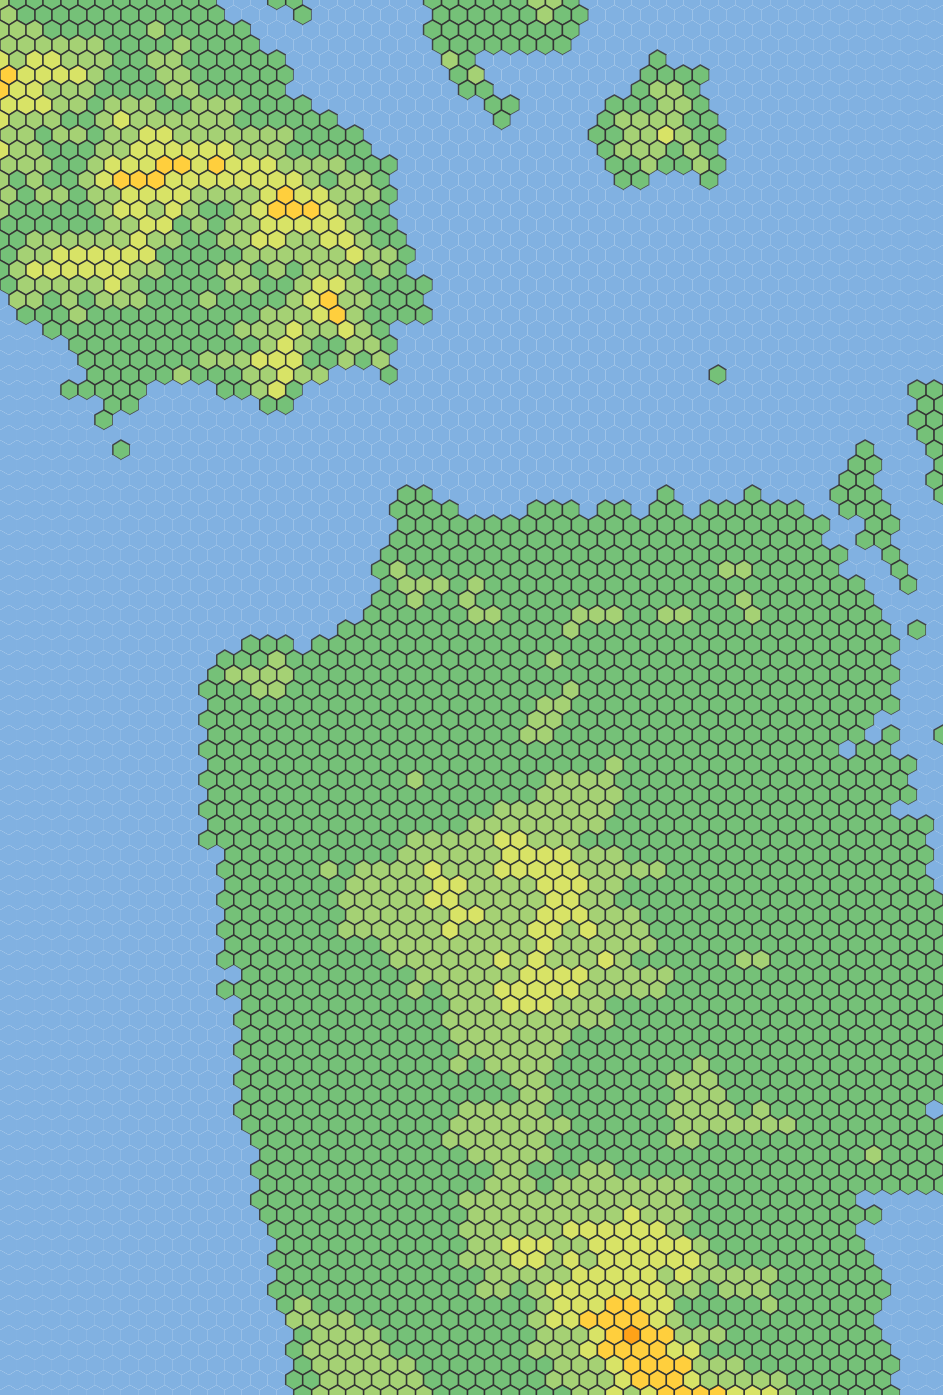

In [ ]:
with open('sf_coast_weather.txt') as f:
    sfTerr = Terrain.decode(f.read())
sfTerr.hexGrid.adjustRadius(10)
sfTerr.colorMap()
sfTerr.hexGrid.update()
sfTerr.builder.show()


In [ ]:
sfTerr.fields.keys()

dict_keys(['latitude', 'longitude', 'temperature', 'precipitation', 'climate_pet', 'aridity_index', 'temp_seasonality', 'precip_seasonality', 'humidity'])

So we have made great progress on a great deal of the steps TerrainSchema.md. I want to put in a section about what we have built so far. are you able to cat to the end of the file. if not put it below and I can add it.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

I can't write to files directly. Here's the section to append to the end of `schemaMain.md`:

```markdown
---

## Implementation Progress

### Completed (2026-02-01)

#### Core Classes

**GeoStorage** - Main database manager
- `__init__(custom_path)` - Initialize with FastLite database
- `get_db_path()` - Package data or user fallback
- `reset_database()` - Delete and recreate (testing)
- `_get(obj, key)` - Dict/object attribute accessor

**Tables Created**
- `TerrainWorld` - World metadata (name, hex_radius, nrows, ncols, sea_level, elevation_delta, extras JSON)
- `HexData` - Per-hex spatial data (world_id, q, r, s, grid_index, elevation, distance_from_coast, modified timestamp)
- `User` - User accounts with activeWorld reference

**Indices**
- `idx_hex_world` - world_id lookup
- `idx_hex_coords` - (world_id, q, r, s) spatial queries
- `idx_hex_grid` - (world_id, grid_index) array-order queries

#### Save/Load Operations

**save_world(terrain, name)** → SaveResult
- Extracts grid parameters (radius, nrows, ncols)
- Stores geo/climate in extras JSON
- Batch inserts all HexData rows with elevation + distance_from_coast
- Returns SaveResult(world_id, status, context)

**load_world(world_id)** → LoadResult
- Reconstructs Terrain from TerrainWorld metadata
- Rebuilds grid with `adjustRadius()`
- Populates elevations and fields from HexData
- Returns LoadResult(terrain, status, context)

#### Spatial Queries

**query_hexes_in_radius(world_id, center_q, center_r, center_s, radius)** → list
- Bounding box SQL query followed by hex distance filter
- Returns list of HexData rows

**extract_region(world_id, center_q, center_r, center_s, rings, padding)** → LoadResult
- Creates centered HexGrid via `HexGrid.centered()`
- Maps DB rows to new grid using HexPosition arithmetic
- Returns LoadResult(terrain, status, context) with centered Terrain

#### Index Mappers

**create_region_coord_mapper(center_q, center_r, center_s, extracted_grid)** → callable
- Returns function: `new_idx → (q, r, s)` in world coordinates

**create_region_index_mapper(world_id, center_q, center_r, center_s, extracted_grid)** → callable
- Builds (q,r,s) → grid_index lookup from DB
- Returns function: `new_idx → original_grid_index` (or -1)

#### Testing

**GeoStorageDebugger** - Test harness with temp database
- Auto-cleanup unless `keep_on_error=True`
- `preserve_db(test_name)` - Copy to ~/.hexmagic/test_failures/

**Tests Passing**
- `test_save_load_terrain()` - Round-trip with elevation verification
- `test_query_radius()` - Spatial query returns expected hexes
- `test_extract_region()` - Centered grid extraction
- `test_region_mappers()` - Coordinate and index mapping

### Next Steps

1. **Downsampling** - `save_downsampled_world()` with ScaleTransform tracking
2. **Print rectangles** - `extract_rectangle()` for landscape/portrait crops
3. **Viewport persistence** - Save/load named viewports
4. **Additional fields** - Temperature, precipitation, watersheds
5. **Template system** - Pre-populate with TerraDemo maps
```

#| export
and how would you update llms.txt

